# Multiple Linear Regression - Credit Dataset

In [56]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as variance_inflation_factor
from statsmodels.stats.anova import anova_lm

from sklearn.model_selection import train_test_split
from scipy import stats

In [57]:
Credit = pd.read_csv("data/Credit.csv")
Credit.head(10)

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331
5,80.180,8047,569,4,77,10,No,No,No,South,1151
6,20.996,3388,259,2,37,12,Yes,No,No,East,203
7,71.408,7114,512,2,87,9,No,No,No,West,872
8,15.125,3300,266,5,66,13,Yes,No,No,South,279
9,71.061,6819,491,3,41,19,Yes,Yes,Yes,East,1350


In [58]:
Credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Income     400 non-null    float64
 1   Limit      400 non-null    int64  
 2   Rating     400 non-null    int64  
 3   Cards      400 non-null    int64  
 4   Age        400 non-null    int64  
 5   Education  400 non-null    int64  
 6   Own        400 non-null    object 
 7   Student    400 non-null    object 
 8   Married    400 non-null    object 
 9   Region     400 non-null    object 
 10  Balance    400 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 34.5+ KB


In [59]:
Credit.describe()

,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


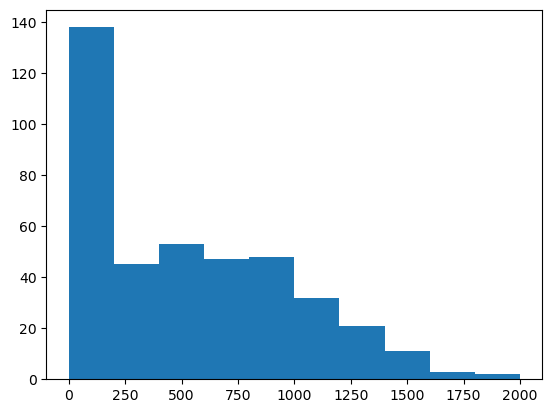

In [60]:
plt.hist(x=Credit["Balance"])
plt.show()

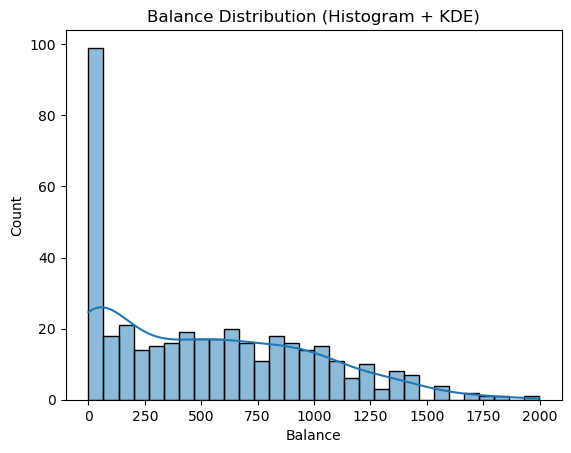

In [61]:
sns.histplot(Credit["Balance"], bins=30, kde=True)
plt.title("Balance Distribution (Histogram + KDE)")
plt.show()

In [62]:
(Credit["Balance"] == 0).mean()*100

np.float64(22.5)

In [63]:
mean = Credit["Balance"].mean()
median = Credit["Balance"].median()
print(f"Balance Mean: {mean} , Balance Median: {median}")

Balance Mean: 520.015 , Balance Median: 459.5


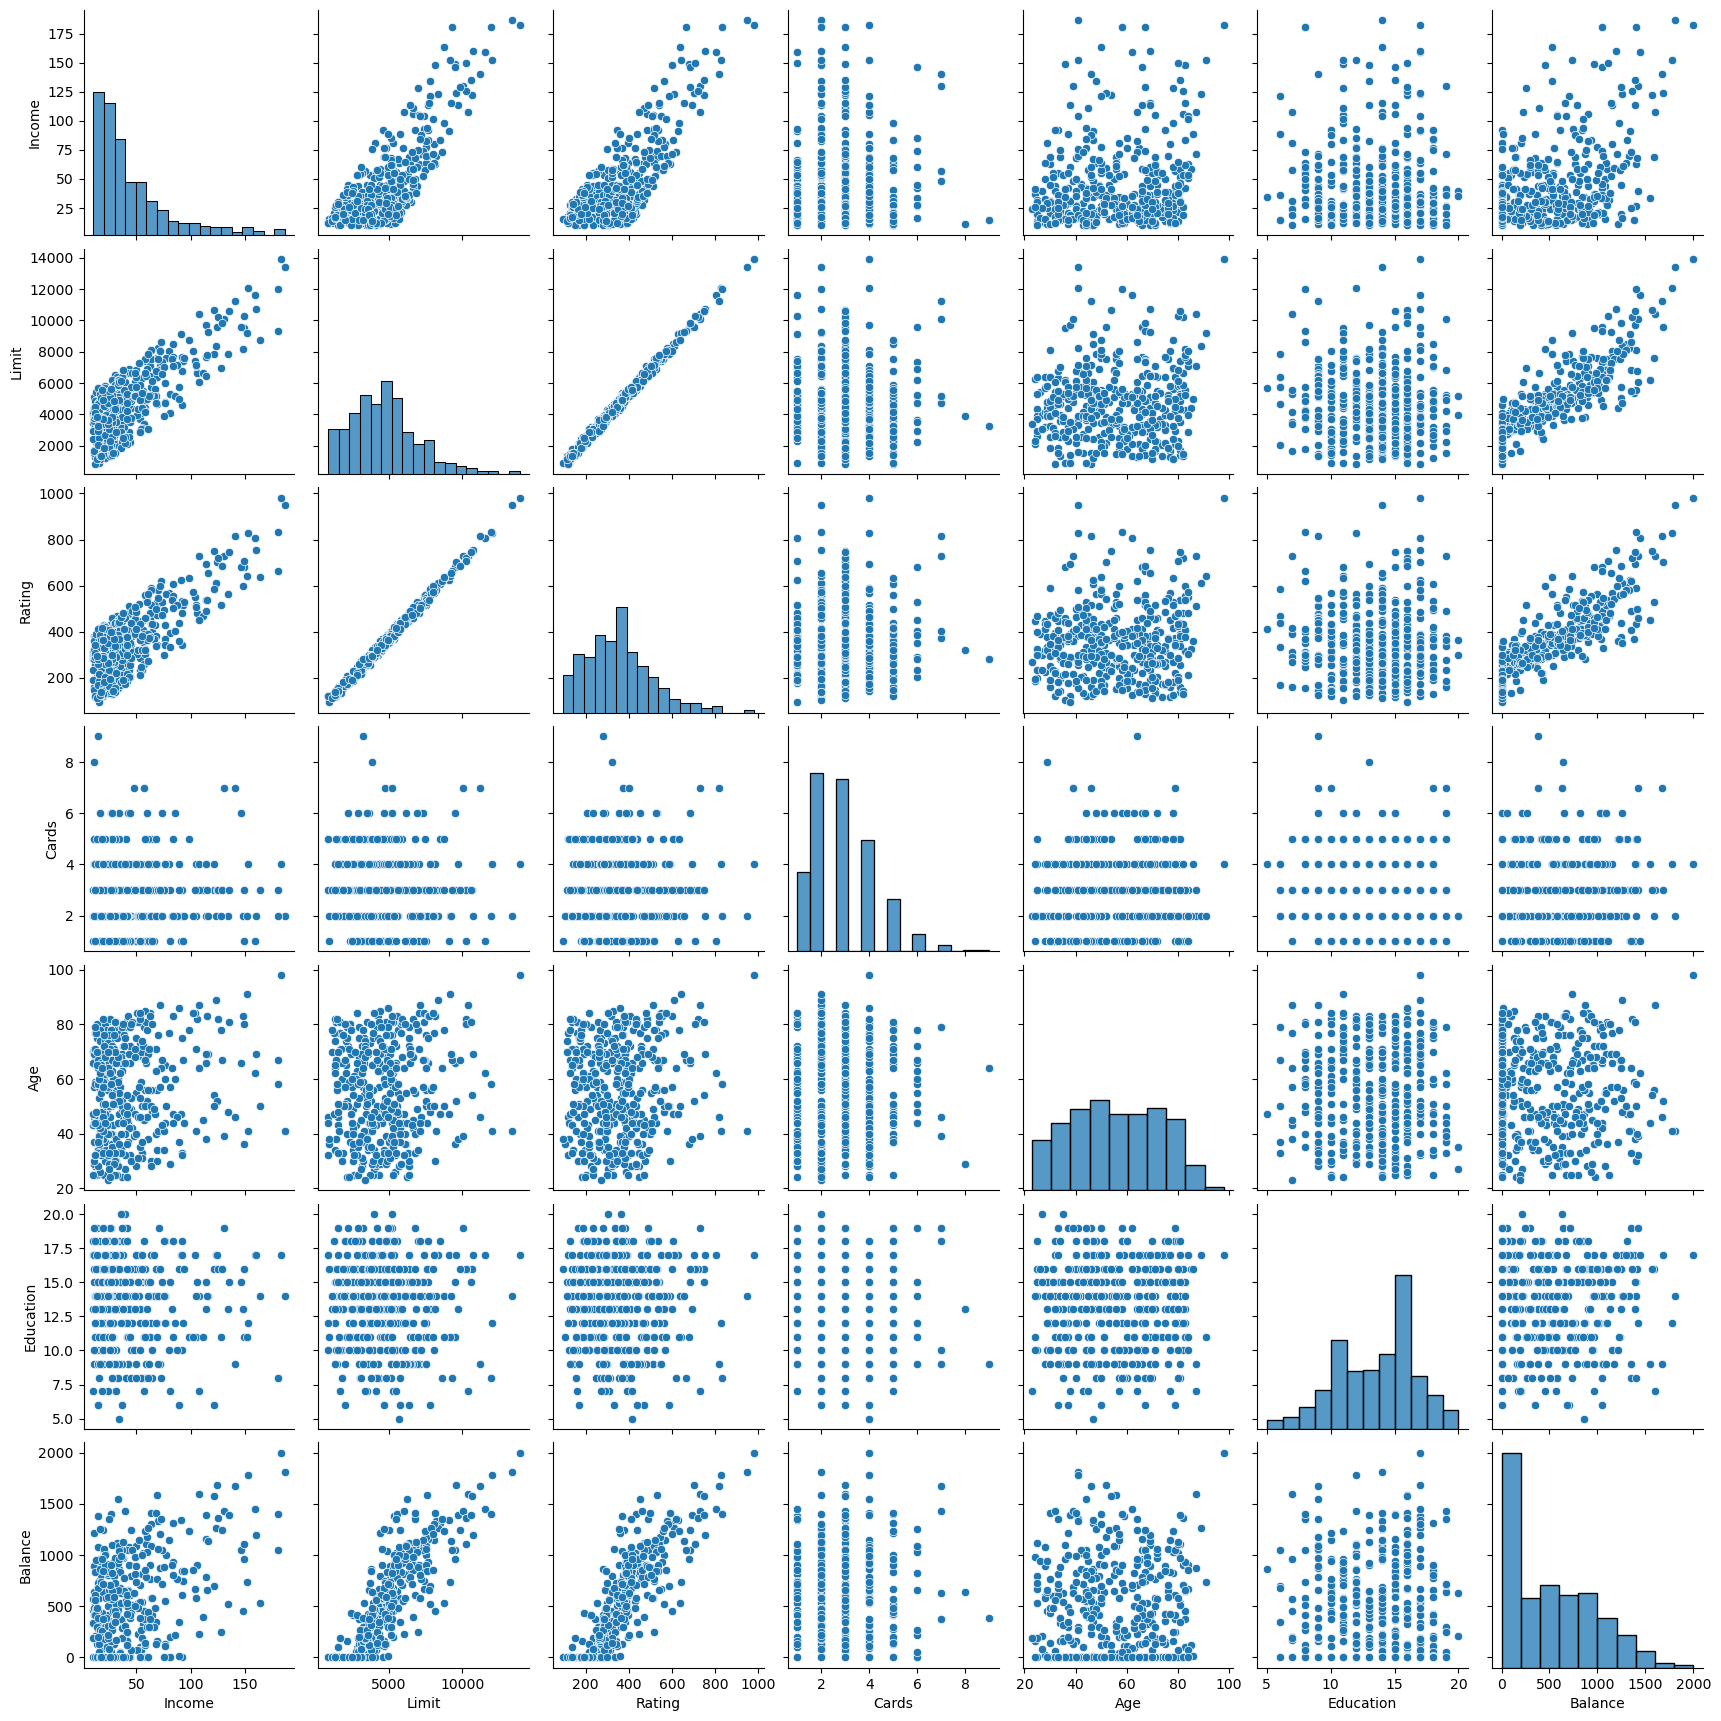

In [109]:
# confusing for large number of numeric predictors
sns.pairplot(Credit)

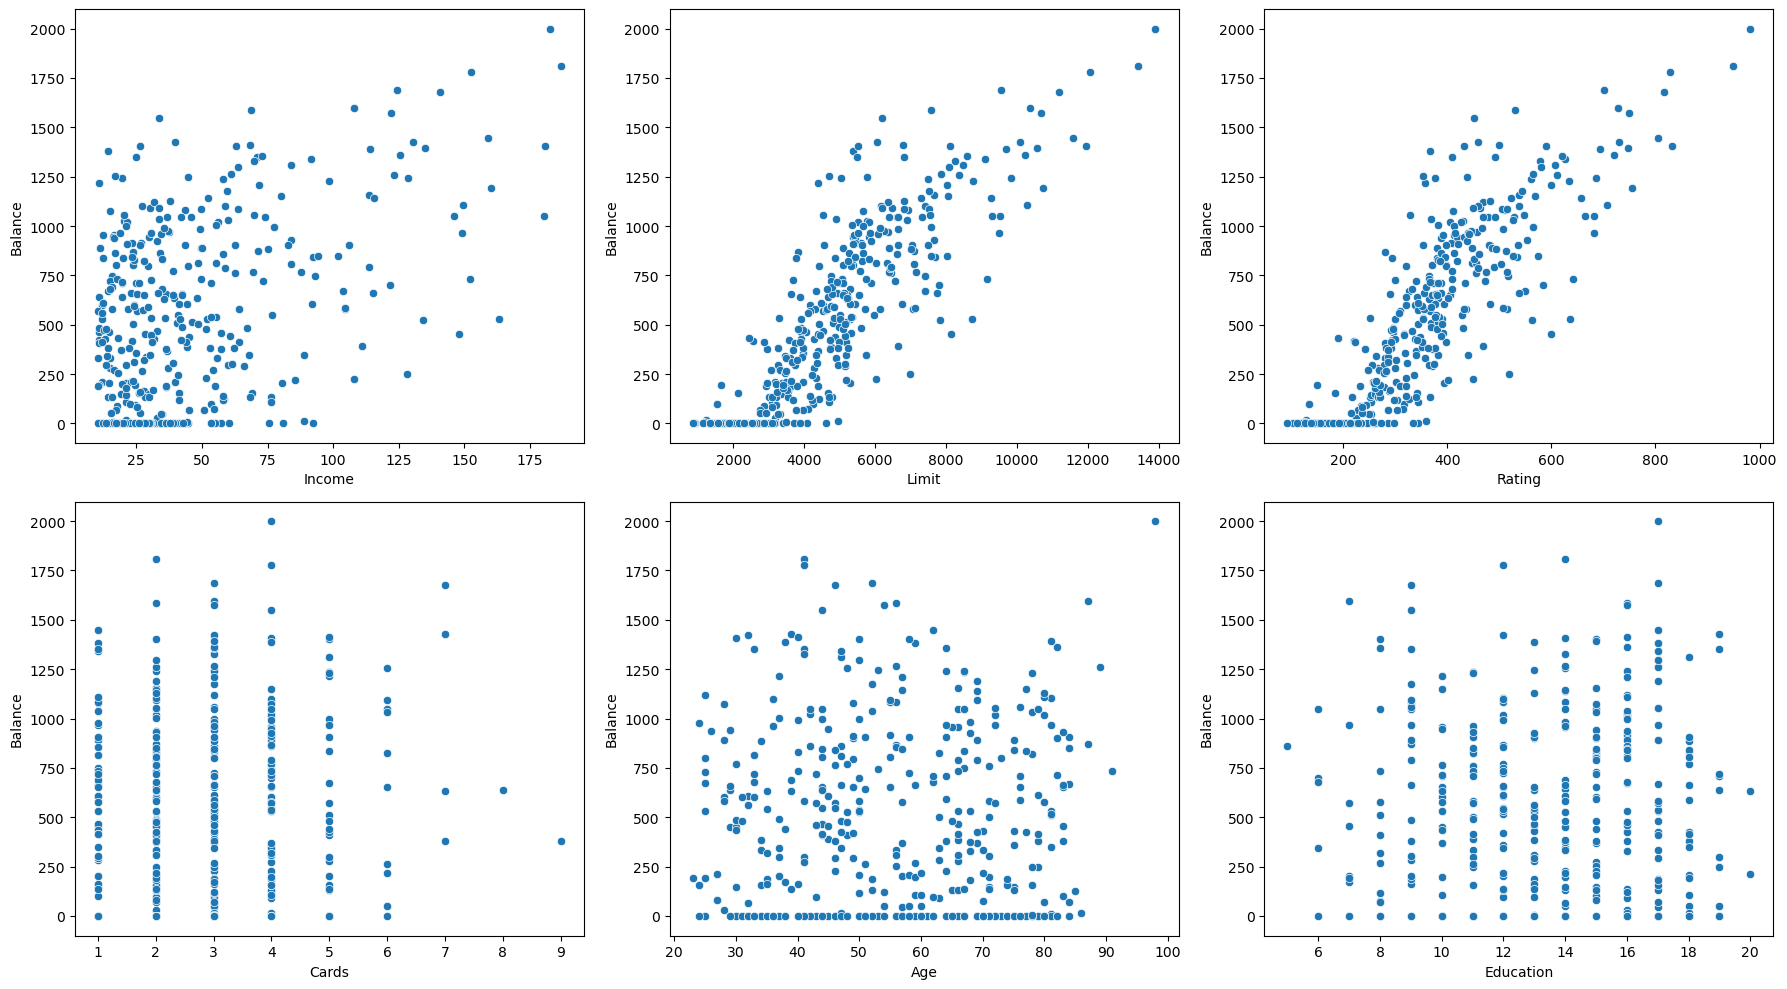

In [65]:
# Scatter plot for Numerical Predictors
fign, axn = plt.subplots(2, 3, figsize=(18,10))

sns.scatterplot(ax=axn[0, 0], x="Income", y="Balance", data=Credit)
sns.scatterplot(ax=axn[0, 1], x="Limit",  y="Balance", data=Credit)
sns.scatterplot(ax=axn[0, 2], x="Rating", y="Balance", data=Credit)

# These Predictors are not that helpful 
sns.scatterplot(ax=axn[1, 0], x="Cards", y="Balance", data=Credit)
sns.scatterplot(ax=axn[1, 1], x="Age", y="Balance", data=Credit)
sns.scatterplot(ax=axn[1, 2], x="Education", y="Balance", data=Credit)


plt.tight_layout()
plt.show()



<Axes: xlabel='Own', ylabel='Balance'>

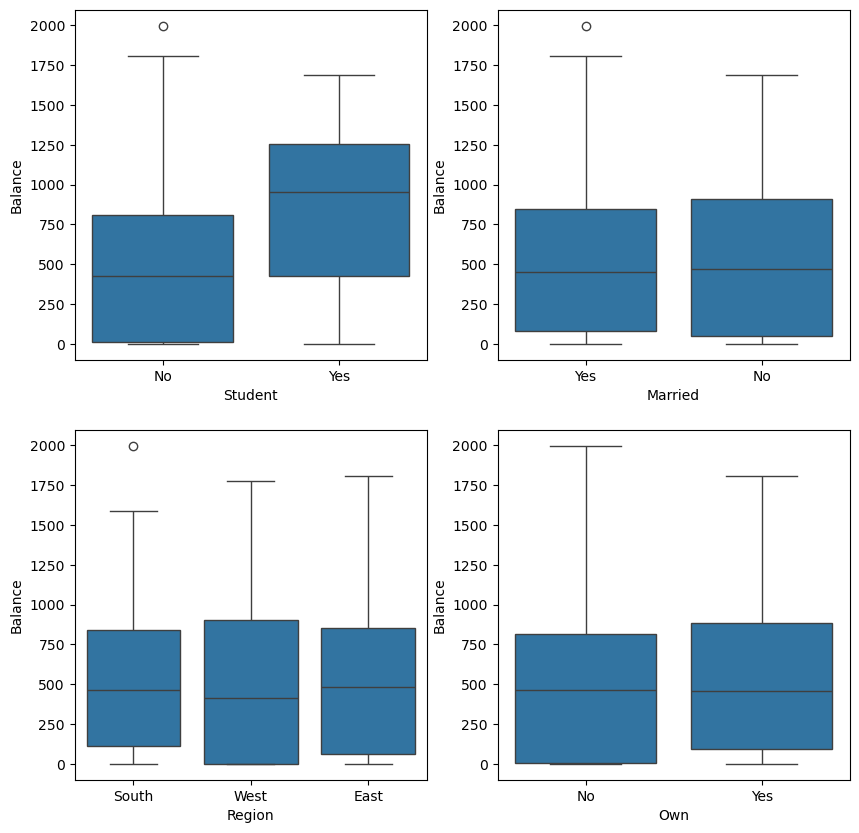

In [66]:
# Box Plot for Categorical Predictors

figc, axc = plt.subplots(2, 2, figsize=(10, 10))

sns.boxplot(ax=axc[0, 0], x="Student", y="Balance", data=Credit)
sns.boxplot(ax=axc[0, 1], x="Married", y="Balance", data=Credit)
sns.boxplot(ax=axc[1, 0], x="Region", y="Balance", data=Credit)
sns.boxplot(ax=axc[1, 1], x="Own", y="Balance", data=Credit)


In [67]:
Credit.groupby("Student")["Balance"].mean()

Student
No     480.369444
Yes    876.825000
Name: Balance, dtype: float64

In [68]:
# Correlation Matrix of Predictors
Credit.select_dtypes(include=["float64", "int64"]).corr()

# Income, Limit and Rating seems to have good coorelation with response, 
# but Limit and Rating have a very high correlation among them ??
# need to check VIF for these predictors

,Income,Limit,Rating,Cards,Age,Education,Balance
Income,1.000000,0.792088,0.791378,-0.018273,0.175338,-0.027692,0.463656
Limit,0.792088,1.000000,0.996880,0.010231,0.100888,-0.023549,0.861697
Rating,0.791378,0.996880,1.000000,0.053239,0.103165,-0.030136,0.863625
Cards,-0.018273,0.010231,0.053239,1.000000,0.042948,-0.051084,0.086456
Age,0.175338,0.100888,0.103165,0.042948,1.000000,0.003619,0.001835
Education,-0.027692,-0.023549,-0.030136,-0.051084,0.003619,1.000000,-0.008062
Balance,0.463656,0.861697,0.863625,0.086456,0.001835,-0.008062,1.000000


## Variance Inflation Factor 

VIF is a way to quantify "how better can we estimate predictor j using rest of the predictors" , if we are able to do so , it clearly means that there exist some other predictor which behaves similar to the predictor j.

hence conferming that predictor j is correlated with some other predictor also, this is what we see in the correlation matrix (for numeric predictors), but here we go again!

$$
VIF_{j} = \frac{1}{1-R^2_{j | p-j}}
$$
where p is the total number of predictors, but no one uses this formula , in practice prefer to calculate **Gram Matrix Inverse** , since its matrix and could be calculated using programs ,

$$
VIF_{j} = [(X^T X)^{-1}]_{jj} . \sum_{i = 1}^{n} (x_{ji} - \bar{x}_j)
$$

Sincce I am not centering the data here (too lazy, dont wanna) , so I am using this formula , if you center the data then you can drop the summation term and the diagonal element would be desired result.

**NOTE** : The first diagonal element of VIF matrix is kinda useless in contex of calculating VIF. So ignore it !!!



In [101]:
# lessss gooo
X = Credit[["Income", "Limit", "Rating"]]
# X = X.assign(**{col: X[col] - X[col].mean() for col in X.columns})  # quite clever
X = sm.add_constant(X)
X = X.rename(columns={"const":"Intercept"})
X

,Intercept,Income,Limit,Rating
0,1.0,14.891,3606,283
1,1.0,106.025,6645,483
2,1.0,104.593,7075,514
3,1.0,148.924,9504,681
4,1.0,55.882,4897,357
...,...,...,...,...
395,1.0,12.096,4100,307
396,1.0,13.364,3838,296
397,1.0,57.872,4171,321
398,1.0,37.728,2525,192


In [102]:
vif = np.linalg.inv(X.T @ X)
vif

array([[ 3.90893837e-02,  7.88080330e-05,  4.03760465e-05,
        -6.51822282e-04],
       [ 7.88080330e-05,  5.42240704e-06, -4.22565992e-08,
        -3.49053029e-07],
       [ 4.03760465e-05, -4.22565992e-08,  7.58276702e-08,
        -1.12006188e-06],
       [-6.51822282e-04, -3.49053029e-07, -1.12006188e-06,
         1.68247341e-05]])

In [103]:
vif_p = {X.columns[i]:vif[i, i].item() for i in [1, 2, 3]}
vif_p

{'Income': 5.422407041942976e-06,
 'Limit': 7.582767016948415e-08,
 'Rating': 1.6824734119852856e-05}

In [107]:
income_mean = X["Income"].mean()
income_vif = ((X["Income"] - income_mean)**2).sum() * vif_p["Income"]
income_vif

np.float64(2.6874607394938246)

In [108]:
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

print(vif_df)

     feature         VIF
0  Intercept   15.635753
1     Income    2.687461
2      Limit  161.193323
3     Rating  160.707918


In [ ]:
-p